In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import math
import functools

In [39]:
plt.style.use('../../default_colors.mplstyle')

In [28]:
@functools.lru_cache
def C(n, k):
    """Число сочетаний из n по k"""
    return math.comb(n, k)
    # Для версий Python < 3.8    
    #return math.factorial(n) // (math.factorial(n-k) * math.factorial(k))

In [34]:
def B(n, i, t):
    """Полиномы Бернштейна"""
    if (n < i or i < 0):
        return 0.0
    elif (i==0 and n==0):
        return 1.0
    else:
        return t * B(n-1, i-1, t) + (1 - t) * B(n-1, i, t)

In [29]:
def B(n, i, t):
    """Полиномы Бернштейна"""
    return C(n, i) * (t**i) * (1-t)**(n-i)

In [31]:
def Bezier(t, points):
    """Более быстрая реализация полинома кривой Безье"""
    n = len(points)
    res = np.zeros_like(points[0])
    for (i, point) in enumerate(points):
        res += B(n-1, i, t) * point
    return res

In [33]:
T = np.linspace(0, 1, 100)

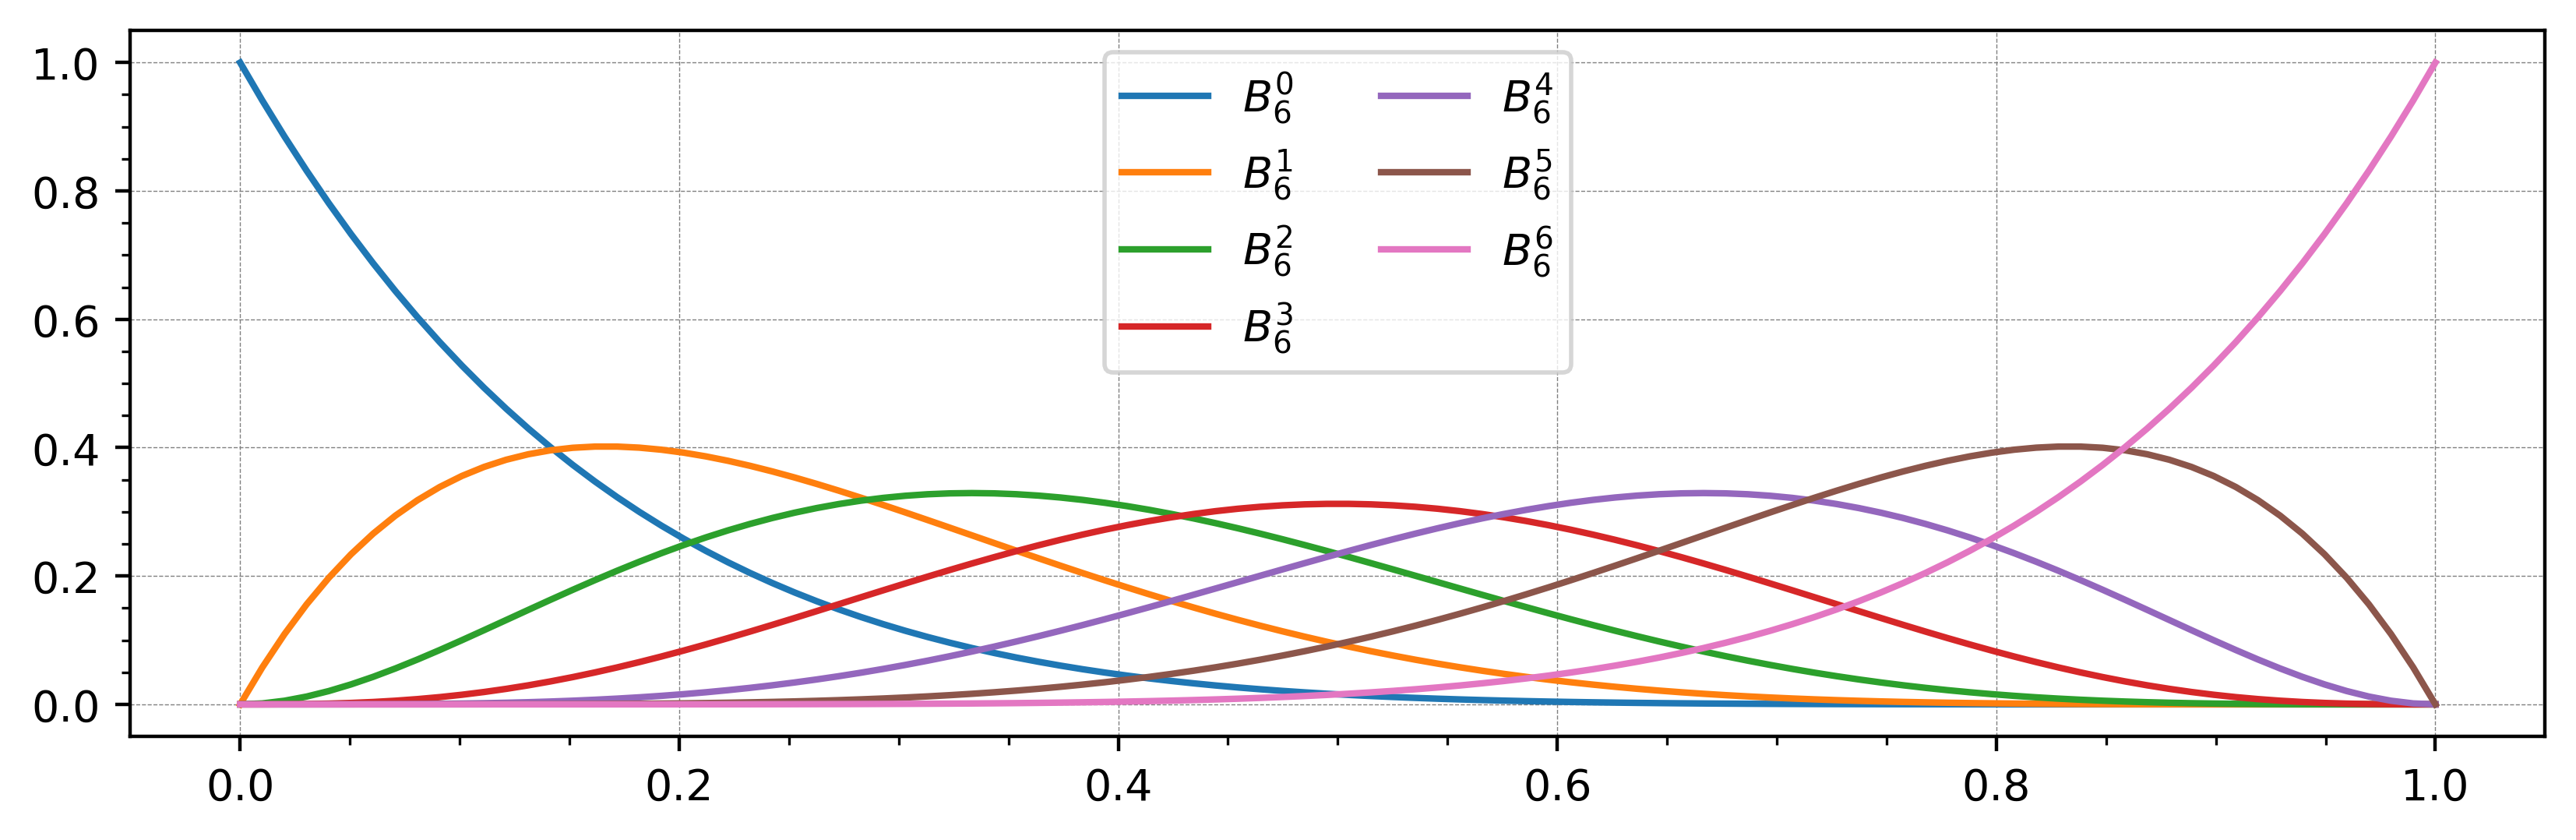

In [33]:
fig01 = plt.figure(1, figsize=(10, 3))
ax01 = fig01.add_subplot(1,1,1)

n = 6
for i in range(n+1):
    ax01.plot(T, B(n, i, T), markersize=6, markevery=10, label=f'$B^{{{i}}}_{{{n}}}$')

ax01.legend(ncol=2)

In [42]:
points = [(1, 1), (5, 3), (1, 3), (2, 2)]
points = np.array(points, dtype=np.float64)
Bs3 = np.array([Bezier(t, points) for t in T]).T

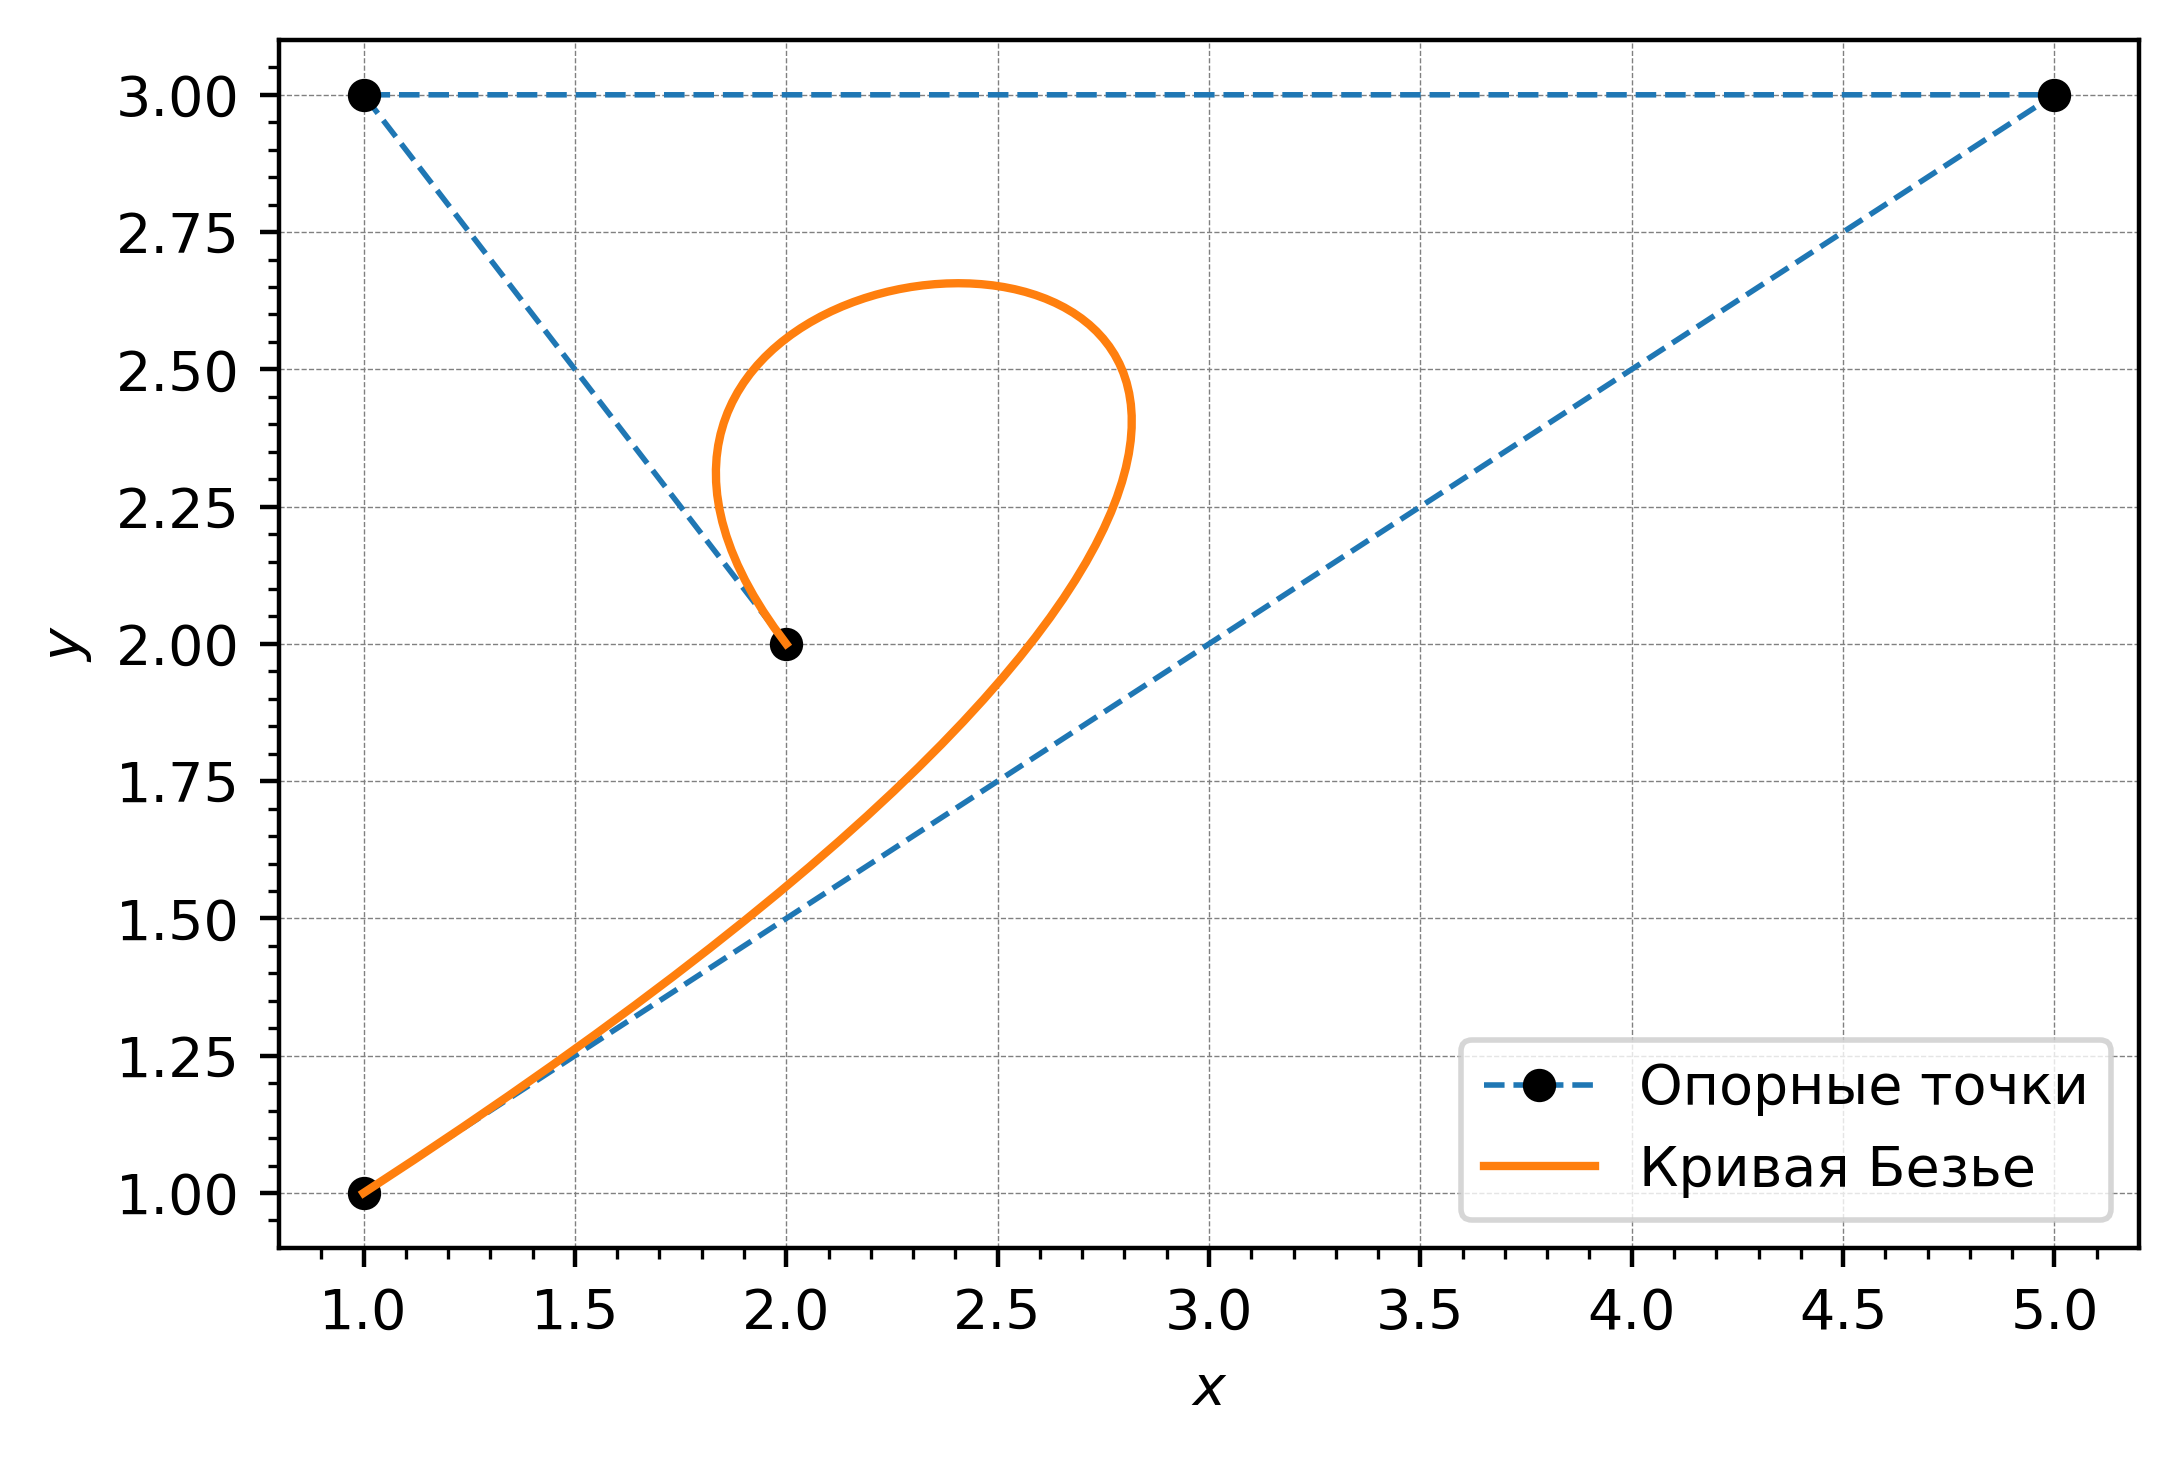

In [43]:
fig02 = plt.figure(2)
ax02 = fig02.add_subplot(1,1,1)

#02.set_aspect('equal')

ax02.plot(*zip(*points), markersize=5, marker='o', lw=1.0, markeredgecolor='k',
          markerfacecolor='k', ls='--', label='Опорные точки')

ax02.plot(*Bs3, marker='None', label='Кривая Безье')

ax02.set_xlabel('$x$')
ax02.set_ylabel('$y$')
ax02.legend(loc='best')